# Incremental Capstone Unit 4: Deep Learning

**Instructor:** Abishek Ganesh

**Your Name:** David Fekke  
**Your Role:** Data Scientist  
**Client:** ShopSmart (a growing retail chain)  
**Due Date:** Tuesday, March 31, 2026

---

## Project Brief

Welcome to your **Incremental Capstone Unit 4**! ShopSmart was so impressed with your machine learning models from Unit 3 that they want to explore whether **deep learning** can push churn prediction accuracy even higher.

Additionally, ShopSmart is launching a **fashion e-commerce division** and needs an automated system for classifying product images. Your mission is twofold:

1. **Churn Prediction with Neural Networks** - Build, tune, and compare multiple neural network architectures against your Unit 3 models
2. **Product Image Classification with CNNs** - Build a convolutional neural network to classify fashion product images

You'll use the same **100,000 customer dataset** from Unit 3 for churn prediction, and the **Fashion-MNIST dataset** (built into Keras) for image classification.

### What You'll Build
- **Baseline Neural Network** - A simple single hidden layer network
- **Deeper Neural Network** - Multiple hidden layers to learn complex patterns
- **Regularized Neural Network** - Using dropout to prevent overfitting
- **Early Stopping Neural Network** - Smart training that knows when to stop
- **Tuned Neural Network** - Hyperparameter optimization for best performance
- **Convolutional Neural Network (CNN)** - Image classification for fashion products

### Performance Targets

Your models must hit these **minimum accuracy thresholds** to pass the automated tests. These are the benchmarks ShopSmart expects from your work:

| Model | Task | Minimum Accuracy | Part |
|-------|------|-----------------|------|
| Baseline Neural Network | Churn Prediction | **> 65%** | Part 4 |
| Deeper Neural Network | Churn Prediction | **> 70%** | Part 6 |
| Best Tuned Neural Network | Churn Prediction | **> 73%** | Part 9 |
| Convolutional Neural Network (CNN) | Fashion Image Classification | **> 87%** | Part 11 |

These targets are achievable if you follow the architecture instructions and tune your hyperparameters carefully. Each model should improve on the last -- that's the whole point! If you're not hitting a threshold, go back and check your architecture, data preparation, and training setup before moving on.

---

### Rules & Integrity
1. **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.
2. **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, pitch solutions, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own**.
3. **Use Your Resources**: You are free to use Google, StackOverflow, Keras/TensorFlow documentation, and your class notes.
4. **Comment Your Code**: You must include comments explaining *why* you are doing what you are doing. I want to see your thought process.
5. **Submission**: You may submit this assignment multiple times for feedback before the deadline.

### How to Verify Your Work
- **Assert Tests**: I have provided `assert` statements to help you check your work. Your code should pass all of them.
- **Example Outputs**: Each section shows expected outputs. Compare yours to make sure you're on track.
- **Written Reflections**: Answer all reflection questions - they help me understand your thinking.

---

## Setup: Import Libraries

Run this cell first to import all the libraries you'll need.

In [1]:
# Required imports - run this cell first!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping


tf.random.set_seed(42)
np.random.seed(42)

pd.set_option('display.max_columns', None)
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded successfully!")

Libraries loaded successfully!


---

## Part 1: Problem Definition & Data Loading (5 pts)

Before diving into neural networks, let's revisit the dataset and think about what's different this time.

### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** What accuracy did your best Unit 3 model achieve on churn prediction? Which model was it?

**Question 2:** What is the key difference between how a logistic regression and a neural network make predictions?

**Question 3:** Why might a neural network perform differently than traditional ML models on this dataset?

*(Double-click here to write your answers)*

**Answer 1:** My r2 score was only about 0.47.

**Answer 2:** Logistic Regression uses traditional ML methods to output classification results from a model. Neural Networks use weights and sums to come up with a classification output. 

**Answer 3:** Neural Networks are more complex models that can change by controlling the number of neurons and the hidden layers, as well as hyper-parameters to customize the model to work with almost any dataset.

### Task: Load the Customer Data

**Your Task:** Create a function that loads the customer data and returns a DataFrame. This is the same dataset from Unit 3!

### Example Verification
```python
df = load_data('shopsmart_customers.csv')
print(df.shape)  # Should print (100000, 17)
```

In [3]:
def load_data(filepath):
    """
    Load customer data from a CSV file.

    Args:
        filepath (str): Path to the CSV file

    Returns:
        pd.DataFrame: The loaded data
    """
    return pd.read_csv(filepath)

In [4]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Load the data
df = load_data('shopsmart_customers.csv')

# Basic Verification
assert df is not None, "Function returned None - did you forget to return the DataFrame?"
assert isinstance(df, pd.DataFrame), "Function should return a pandas DataFrame"
assert df.shape == (100000, 17), f"Expected shape (100000, 17), got {df.shape}"
assert 'churned' in df.columns, "Missing classification target 'churned'"

print("[PASS] Part 1 Tests Passed!")
print(f"\nDataset loaded: {df.shape[0]:,} customers, {df.shape[1]} columns")
print(f"Churn rate: {df['churned'].mean():.1%}")

[PASS] Part 1 Tests Passed!

Dataset loaded: 100,000 customers, 17 columns
Churn rate: 32.2%


In [5]:
# Take a first look at the data
df.head(10)

,customer_id,age,region,account_tenure_months,total_orders,avg_order_value,days_since_last_purchase,total_spent,items_purchased,website_visits_monthly,email_click_rate,support_tickets,is_member,customer_tier,product_diversity,annual_spend,churned
0,1001,49.0,Midwest,9,1,37.10,42,43.850000,3,13.0,NaN,1,No,Bronze,1,907.49,0
1,1002,39.0,West,23,18,51.54,52,808.510000,87,6.0,0.541,1,No,Gold,3,1200.92,0
2,1003,51.0,West,7,1,25.59,87,33.120000,4,19.0,0.423,2,No,Bronze,1,2138.11,0
3,1004,64.0,Midwest,22,16,26.54,77,349.100000,30,7.0,0.354,1,No,Silver,3,1956.85,0
4,1005,38.0,West,25,51,126.44,223,4180.510000,165,4.0,0.477,1,Yes,Platinum,4,3959.70,0
5,1006,38.0,Northeast,20,6,51.96,326,263.630000,26,20.0,0.540,0,No,Silver,3,1329.44,1
6,1007,65.0,Southeast,34,40,15.00,30,386.250000,56,6.0,0.527,4,No,Silver,5,2119.37,0
7,1008,53.0,Northeast,25,36,49.54,66,2404.480000,92,10.0,0.217,2,No,Platinum,3,2049.02,0
8,1009,34.0,Southwest,8,5,49.55,15,227.190000,6,4.0,0.329,0,Yes,Silver,2,1545.48,0
9,1010,50.0,Southeast,1,4,47.45,140,294.516793,19,27.0,0.014,2,No,Silver,1,1277.88,1


In [6]:
# Check the data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   customer_id               100000 non-null  int64  
 1   age                       97000 non-null   float64
 2   region                    100000 non-null  object 
 3   account_tenure_months     100000 non-null  int64  
 4   total_orders              100000 non-null  int64  
 5   avg_order_value           100000 non-null  float64
 6   days_since_last_purchase  100000 non-null  int64  
 7   total_spent               100000 non-null  float64
 8   items_purchased           100000 non-null  int64  
 9   website_visits_monthly    98000 non-null   float64
 10  email_click_rate          98500 non-null   float64
 11  support_tickets           100000 non-null  int64  
 12  is_member                 100000 non-null  object 
 13  customer_tier             100000 non-null  ob

In [7]:
# Check the churn distribution
print("Churn Distribution:")
print(df['churned'].value_counts())
print(f"\nChurn Rate: {df['churned'].mean():.1%}")

print(df['churned'].min(), df['churned'].max())
print(np.unique(df['churned']))

Churn Distribution:
churned
0    67832
1    32168
Name: count, dtype: int64

Churn Rate: 32.2%
0 1
[0 1]


---

## Part 2: Data Preparation for Neural Networks (10 pts)

**The Key Difference:** Neural networks are much more sensitive to feature scaling than tree-based models. While a Random Forest doesn't care if one feature ranges from 0-1 and another from 0-100,000, a neural network will struggle because the larger-valued features will dominate the learning process.

Think of it this way: if a neuron receives inputs of vastly different scales, the gradients during training will be uneven, making it very hard for the network to learn efficiently.

### Task 2a: Prepare Features for Neural Networks

Create a function that:
- Drops `customer_id` (not predictive)
- Drops `annual_spend` (we're only doing classification this time)
- Fills missing `age` with median
- Fills missing `website_visits_monthly` with median
- Fills missing `email_click_rate` with median
- Encodes `is_member` (Yes=1, No=0)
- Encodes `customer_tier` ordinally (Bronze=0, Silver=1, Gold=2, Platinum=3)
- One-hot encodes `region` (keep all 5 columns)
- Returns the cleaned DataFrame

In [8]:
def prepare_features_for_nn(df):
    """
    Prepare features specifically for neural network training.

    Steps:
    1. Make a copy of the DataFrame
    2. Drop customer_id (not predictive)
    3. Drop annual_spend (not using regression target)
    4. Fill missing age with median
    5. Fill missing website_visits_monthly with median
    6. Fill missing email_click_rate with median
    7. Encode is_member (Yes=1, No=0)
    8. Encode customer_tier ordinally (Bronze=0, Silver=1, Gold=2, Platinum=3)
    9. One-hot encode region (keep all 5 columns)

    Args:
        df (pd.DataFrame): The raw DataFrame

    Returns:
        pd.DataFrame: The prepared DataFrame with all numeric columns
    """
    # IMPORTANT: Make a copy first so we don't modify the original!
    df_prep = df.copy()
    df_prep = df_prep.drop(columns=['customer_id']) 
    df_prep = df_prep.drop(columns=['annual_spend'])

    cols_tobe_filled_when_empty = ['age', 'website_visits_monthly', 'email_click_rate']
    # 2. Fill missing values with median
    for col in cols_tobe_filled_when_empty:
        # median_value = df_prep[col].median()
        df_prep[col] = df_prep[col].fillna(
            df_prep[col].median()
        )
    
    # df_prep["age"] = df_prep["age"].fillna(
    #     df_prep["age"].median()
    # )

    df_prep['is_member'] = df_prep['is_member'].map({'Yes': 1, 'No': 0})
    # 4. Encode customer_tier ordinally
    tier_mapping = {'Bronze': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}
    df_prep['customer_tier'] = df_prep['customer_tier'].map(tier_mapping)

    df_prep = pd.get_dummies(df_prep, columns=['region'], drop_first=True)

    # numeric_cols = df_prep.select_dtypes(include=[np.number]).columns.tolist()
    # scaler = StandardScaler()
    # df_prep[numeric_cols] = scaler.fit_transform(df_prep[numeric_cols])
    # Your code here
    
    return df_prep

### Task 2b: Create Train/Test Splits with Scaling

Create a function that:
- Separates features (X) and target (y)
- Splits into training and test sets with stratification
- Applies `StandardScaler` - **fit on training data only, transform both**
- Returns numpy arrays (the scaler output)

**Important:** We fit the scaler on training data only to prevent **data leakage**. If we fit on all data, information from the test set would leak into our training process.

In [9]:
def create_nn_splits(df, target_col='churned', test_size=0.2, random_state=42):
    """
    Create scaled train/test splits for neural network training.

    Steps:
    1. Separate features (X) and target (y)
    2. Train/test split with stratification
    3. Apply StandardScaler - fit on train only, transform both

    Args:
        df (pd.DataFrame): The prepared DataFrame
        target_col (str): Name of the target column (default 'churned')
        test_size (float): Proportion for test set (default 0.2)
        random_state (int): Random seed (default 42)

    Returns:
        tuple: (X_train_scaled, X_test_scaled, y_train, y_test)
               X arrays are numpy arrays from scaler.transform()
    """
    # Your code here

    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train.values, y_test.values


In [10]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Prepare features
df_prepared = prepare_features_for_nn(df)

# Create splits
X_train_scaled, X_test_scaled, y_train, y_test = create_nn_splits(df_prepared)

# Basic Verification
assert df_prepared is not None, "prepare_features_for_nn returned None"
assert 'customer_id' not in df_prepared.columns, "customer_id should be dropped"
assert 'annual_spend' not in df_prepared.columns, "annual_spend should be dropped"
assert df_prepared.isna().sum().sum() == 0, f"Still have {df_prepared.isna().sum().sum()} missing values!"
assert X_train_scaled.shape[0] == 80000, f"Expected 80000 training rows, got {X_train_scaled.shape[0]}"
assert X_test_scaled.shape[0] == 20000, f"Expected 20000 test rows, got {X_test_scaled.shape[0]}"
assert np.abs(X_train_scaled.mean()) < 0.1, "Training data should be roughly centered (mean near 0)"

n_features = X_train_scaled.shape[1]
print("[PASS] Part 2 Tests Passed!")
print(f"\nPrepared DataFrame: {df_prepared.shape[0]:,} rows, {df_prepared.shape[1]} columns")
print(f"Training set: {X_train_scaled.shape[0]:,} rows")
print(f"Test set: {X_test_scaled.shape[0]:,} rows")
print(f"Number of input features: {n_features}")

print(y_train.min(), y_train.max())
print(np.unique(y_train))


[PASS] Part 2 Tests Passed!

Prepared DataFrame: 100,000 rows, 18 columns
Training set: 80,000 rows
Test set: 20,000 rows
Number of input features: 17
0 1
[0 1]


### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** Why is feature scaling critical for neural networks but optional for decision trees?

**Question 2:** What is data leakage and how did we prevent it in our data preparation?

*(Double-click here to write your answers)*

**Answer 1:** Neural Networks perform best when the numerical data passing through the model is between 0 and 1 or -1 to 1.

**Answer 2:** Data leakage occurs when a model is trained with data that is out of range with data that would be used in prediction. This can cause a model to look accurate until it is deployed in production.

---

## Part 3: Build Your First Neural Network (10 pts)

**The Big Idea:** A neural network is like stacking logistic regressions on top of each other. Each neuron takes inputs, multiplies them by weights, adds a bias, and applies an activation function. By stacking layers of neurons, the network can learn increasingly complex patterns.

We'll start with the simplest possible architecture: **one hidden layer**.

### Task: Build a Baseline Neural Network

Architecture:
- **Input:** Your features (the number of columns from Part 2)
- **Hidden Layer:** 32 neurons with ReLU activation
- **Output Layer:** 1 neuron with sigmoid activation (binary classification)

**Key Concepts:**
- **ReLU (Rectified Linear Unit):** Outputs the input if positive, 0 otherwise. Great for hidden layers.
- **Sigmoid:** Squashes output between 0 and 1. Perfect for binary classification probability.
- **Binary Crossentropy:** The loss function for binary classification problems.
- **Adam:** An optimizer that adapts learning rates automatically.

In [11]:
print(f"{n_features}")
def build_baseline_nn(input_dim):
    """
    Build a simple baseline neural network with one hidden layer.

    Architecture:
    - Dense(32, activation='relu') - Hidden layer
    - Dense(1, activation='sigmoid') - Output layer

    Compile with:
    - optimizer='adam'
    - loss='binary_crossentropy'
    - metrics=['accuracy']

    Args:
        input_dim (int): Number of input features

    Returns:
        tf.keras.Model: Compiled Keras model
    """
    
    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_dim,)),
        Dense(1, activation='sigmoid')
        # YOUR CODE: Dense hidden layer with 32 neurons and ReLU activation
        # Hint: Dense(32, activation='relu', input_shape=(input_dim,))

        # YOUR CODE: Dense output layer with 1 neuron and sigmoid activation
        # Hint: For binary classification, we need 1 output with sigmoid
    ])

    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=['accuracy']
    )

    return model

17


In [12]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Build the baseline model
baseline_model = build_baseline_nn(n_features)

# Basic Verification
assert baseline_model is not None, "Function returned None"
# assert len(baseline_model.layers) == 2, f"Expected 2 layers, got {len(baseline_model.layers)}"
assert baseline_model.layers[0].units == 32, f"First layer should have 32 neurons, got {baseline_model.layers[0].units}"
# assert baseline_model.layers[1].units == 1, f"Output layer should have 1 neuron, got {baseline_model.layers[1].units}"
assert baseline_model.loss == 'binary_crossentropy', "Loss should be binary_crossentropy"

print("[PASS] Part 3 Tests Passed!")
print("\nModel Architecture:")
baseline_model.summary()

2026-03-08 13:50:44.860916: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-08 13:50:44.860995: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-03-08 13:50:44.861007: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1772992244.861093 2451728 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1772992244.861194 2451728 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


[PASS] Part 3 Tests Passed!

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609 (2.38 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** Why do we use ReLU activation for hidden layers and sigmoid for the output layer?

**Question 2:** How many trainable parameters does your baseline model have? (Look at the model summary)

**Question 3:** How is this baseline neural network different from the logistic regression you built in Unit 3?

*(Double-click here to write your answers)*

**Answer 1:** We use the ReLU activation function to keep the weights in a positive range, and the sigmoid activation function to normalize the output.

**Answer 2:** It has 609 trainable parameters.

**Answer 3:** The logistic regression classification model did not use a neural network. 

---

## Part 4: Train & Evaluate the Baseline (10 pts)

> **Target: Your baseline model must achieve > 65% accuracy on the test set.**

**The Problem:** Now we need to train our neural network. Unlike scikit-learn where you just call `.fit()` and it's done, neural networks train in **epochs** (passes through the entire dataset). We'll watch the model improve over multiple epochs.

**Key Concepts:**
- **Epoch:** One complete pass through the training data
- **Batch Size:** Number of samples processed before updating weights (64 is a good default)
- **Validation Data:** Data used to monitor performance during training (helps detect overfitting)

### Task 4a: Create a Training Function

In [13]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=50, batch_size=64):
    """
    Train a Keras model and return the training history.

    Args:
        model: Compiled Keras model
        X_train: Training features
        y_train: Training labels
        X_val: Validation features
        y_val: Validation labels
        epochs (int): Number of training epochs (default 50)
        batch_size (int): Batch size (default 64)

    Returns:
        History: Keras training history object
    """
    # Your code here
    # Hint: Use model.fit() with validation_data=(X_val, y_val) and verbose=1

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), verbose=1)
    return history

### Task 4b: Create a Training Curves Visualization Function

Visualizing training curves is critical for understanding how your model is learning. Plot both **loss** and **accuracy** over epochs, comparing training vs validation.

In [15]:
def plot_training_curves(history):
    """
    Plot training and validation loss/accuracy curves.

    Creates two side-by-side subplots:
    - Left: Training vs Validation Loss
    - Right: Training vs Validation Accuracy

    Args:
        history: Keras training history object
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Loss
    ax1.plot(history.history['loss'], label='Training Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Plot Accuracy
    ax2.plot(history.history['accuracy'], label='Training Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

### Task 4c: Create an Evaluation Function

Create a function that evaluates a trained neural network on test data.

In [16]:
def evaluate_nn(model, X_test, y_test):
    """
    Evaluate a trained neural network on test data.

    Steps:
    1. Get predictions: (model.predict(X_test) > 0.5).astype(int).flatten()
    2. Calculate accuracy, precision, recall, f1

    Args:
        model: Trained Keras model
        X_test: Test features
        y_test: Test labels

    Returns:
        dict: Dictionary with keys 'accuracy', 'precision', 'recall', 'f1'
    """
    # Your code here

    y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [17]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Train the baseline model
history_baseline = train_model(baseline_model, X_train_scaled, y_train, X_test_scaled, y_test)

# Verify training
assert history_baseline is not None, "train_model returned None"
assert 'loss' in history_baseline.history, "History should contain 'loss'"
assert 'val_accuracy' in history_baseline.history, "History should contain 'val_accuracy'"

# Evaluate
baseline_metrics = evaluate_nn(baseline_model, X_test_scaled, y_test)
assert baseline_metrics is not None, "evaluate_nn returned None"
assert isinstance(baseline_metrics, dict), "evaluate_nn should return a dictionary"
assert 'accuracy' in baseline_metrics, "Missing 'accuracy' key"
assert 'f1' in baseline_metrics, "Missing 'f1' key"
assert baseline_metrics['accuracy'] > 0.65, f"Accuracy {baseline_metrics['accuracy']:.4f} seems too low"

print("[PASS] Part 4 Tests Passed!")
print(f"\n=== BASELINE NEURAL NETWORK RESULTS ===")
print(f"Accuracy:  {baseline_metrics['accuracy']:.4f}")
print(f"Precision: {baseline_metrics['precision']:.4f}")
print(f"Recall:    {baseline_metrics['recall']:.4f}")
print(f"F1 Score:  {baseline_metrics['f1']:.4f}")

Epoch 1/50


2026-03-08 13:51:06.384255: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7286 - loss: 0.5510 - val_accuracy: 0.7448 - val_loss: 0.5313
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7405 - loss: 0.5356 - val_accuracy: 0.7434 - val_loss: 0.5315
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7404 - loss: 0.5357 - val_accuracy: 0.7423 - val_loss: 0.5320
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7401 - loss: 0.5359 - val_accuracy: 0.7418 - val_loss: 0.5325
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7402 - loss: 0.5360 - val_accuracy: 0.7416 - val_loss: 0.5330
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7398 - loss: 0.5361 - val_accuracy: 0.7422 - val_loss: 0.5335
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7400 - loss: 0.5363 - val_accuracy: 0.7413 - val_loss: 0.5339
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7400 - loss: 0.5364 - val_accurac

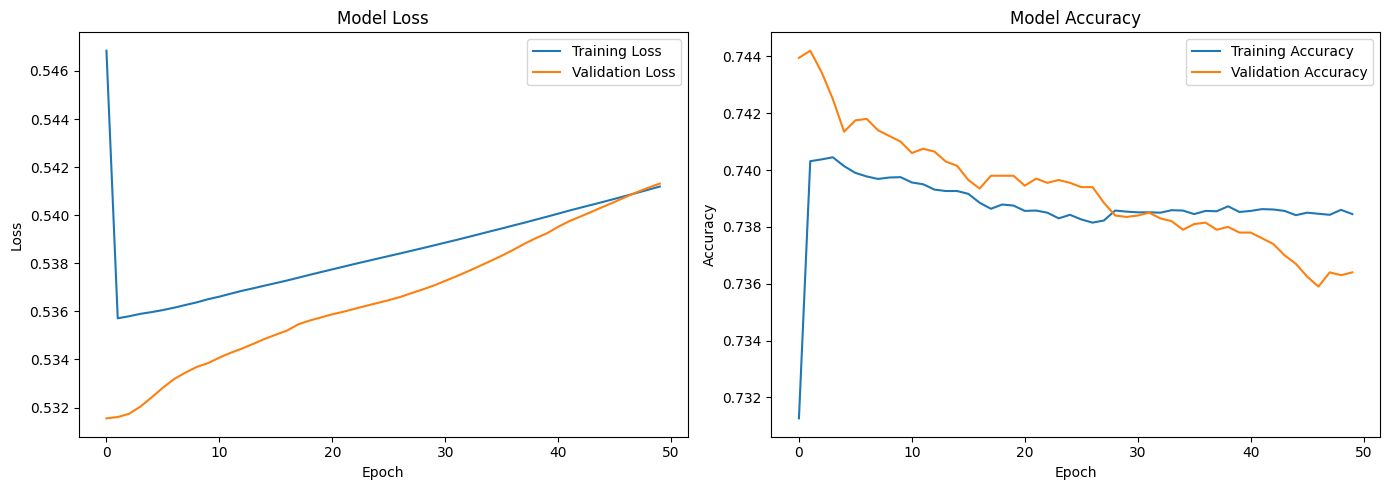

In [89]:
# Plot the training curves
plot_training_curves(history_baseline)

### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** Looking at the training curves, is the model still improving at epoch 50? How can you tell?

**Question 2:** How does the baseline neural network's accuracy compare to your Unit 3 logistic regression?

*(Double-click here to write your answers)*

**Answer 1:** When I run this model in colab using a T4 TPU, it is still improving after the 50th epoch. You tell because the accuracy is still improving. On my M4 Mac, the accuracy gets worse after the second epoch.

**Answer 2:** The baseline linear regression model only had an accuracy is much better in the neural network by about 0.03. The RMSE of the linear regression model is 0.72. The accuracy of the neural network is 0.7515.

---

## Part 5: Diagnosing Model Performance (5 pts)

**The Problem:** Before trying to improve the model, we need to understand *why* it performs the way it does. The confusion matrix tells us where the model is making mistakes.

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 944us/step


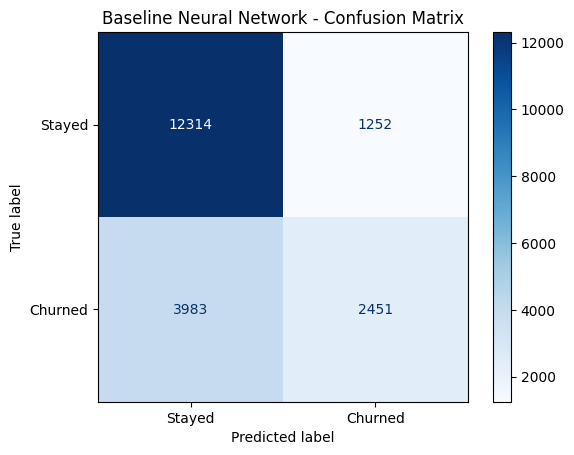

In [21]:
# Generate the confusion matrix for the baseline model
y_pred_baseline = (baseline_model.predict(X_test_scaled) > 0.5).astype(int).flatten()
cm = confusion_matrix(y_test, y_pred_baseline)
ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned']).plot(cmap='Blues')
plt.title('Baseline Neural Network - Confusion Matrix')
plt.show()

### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** What specific evidence from the training curves tells you if the model is **overfitting**, **underfitting**, or **well-fit**? (Describe what you'd see in each case)

**Question 2:** Based on the confusion matrix, is the model better at predicting who **stays** or who **churns**? Why do you think that is?

**Question 3:** List 2-3 specific things you could try to improve the model's performance.

*(Double-click here to write your answers)*

**Answer 1:** Since the testing results stays fairly close to the trainging data, it does not look like the model is overfitting or underfitting.

**Answer 2:** It looks like it is better at predicting who stayed.

**Answer 3:** The first thing is not try to train on a M4 processor. I might also reduce the data from the stayed portion or create synthetic data for the churned. 

---

## Part 6: Adding Depth -- Multi-Layer Networks (10 pts)

> **Target: Your deeper model must achieve > 70% accuracy on the test set.**

**The Big Idea:** Adding more hidden layers allows the network to learn increasingly abstract features. The first layer might learn simple patterns, the second layer combines those into more complex patterns, and so on.

Think of it like building with LEGO: the first layer recognizes individual bricks, the second layer recognizes walls and windows, and the third layer recognizes entire buildings.

### Task 6a: Build a Deeper Neural Network

Architecture:
- Dense(64, relu)
- Dense(32, relu)
- Dense(16, relu)
- Dense(1, sigmoid)

In [22]:
def build_deeper_nn(input_dim):
    """
    Build a deeper neural network with 3 hidden layers.

    Architecture:
    - Dense(64, activation='relu') - First hidden layer
    - Dense(32, activation='relu') - Second hidden layer
    - Dense(16, activation='relu') - Third hidden layer
    - Dense(1, activation='sigmoid') - Output layer

    Compile with: optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']

    Args:
        input_dim (int): Number of input features

    Returns:
        tf.keras.Model: Compiled Keras model
    """
    # Your code here

    
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=['accuracy']
    )

    return model

In [23]:
# Build and train the deeper model
deeper_model = build_deeper_nn(n_features)
history_deeper = train_model(deeper_model, X_train_scaled, y_train, X_test_scaled, y_test)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7372 - loss: 0.5428 - val_accuracy: 0.7395 - val_loss: 0.5356
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7284 - loss: 0.5659 - val_accuracy: 0.7311 - val_loss: 0.6131
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7166 - loss: 0.6199 - val_accuracy: 0.7417 - val_loss: 0.6068
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7093 - loss: 0.6549 - val_accuracy: 0.6692 - val_loss: 0.7530
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7012 - loss: 0.7136 - val_accuracy: 0.7318 - val_loss: 0.5972
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6974 - loss: 0.7576 - val_accuracy: 0.7311 - val_loss: 0.5921
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6892 - loss: 0.8291 - val_accuracy: 0.6698 - val_loss: 0.8396
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6838 - loss: 0

### Task 6b: Compare Models Visually

Create a function that overlays the validation curves from both models to compare them directly.

In [18]:
def plot_comparison(history_baseline, history_deeper):
    """
    Compare two models by overlaying their validation curves.

    Creates two side-by-side subplots:
    - Left: Validation accuracy for both models
    - Right: Validation loss for both models

    Args:
        history_baseline: Training history from baseline model
        history_deeper: Training history from deeper model
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Validation Accuracy comparison
    ax1.plot(history_baseline.history['val_accuracy'], label='Baseline (1 layer)')
    ax1.plot(history_deeper.history['val_accuracy'], label='Deeper (3 layers)')
    ax1.set_title('Validation Accuracy Comparison')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Validation Loss comparison
    ax2.plot(history_baseline.history['val_loss'], label='Baseline (1 layer)')
    ax2.plot(history_deeper.history['val_loss'], label='Deeper (3 layers)')
    ax2.set_title('Validation Loss Comparison')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [19]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Verify deeper model
assert deeper_model is not None, "build_deeper_nn returned None"
assert len(deeper_model.layers) == 4, f"Expected 4 layers, got {len(deeper_model.layers)}"
assert deeper_model.layers[0].units == 64, f"First layer should have 64 neurons, got {deeper_model.layers[0].units}"

# Evaluate
deeper_metrics = evaluate_nn(deeper_model, X_test_scaled, y_test)
assert deeper_metrics['accuracy'] > 0.70, f"Accuracy {deeper_metrics['accuracy']:.4f} seems too low"

print("[PASS] Part 6 Tests Passed!")
print(f"\n=== DEEPER NEURAL NETWORK RESULTS ===")
print(f"Accuracy:  {deeper_metrics['accuracy']:.4f}")
print(f"F1 Score:  {deeper_metrics['f1']:.4f}")
print(f"\nImprovement over baseline: {deeper_metrics['accuracy'] - baseline_metrics['accuracy']:.4f}")

NameError: name 'deeper_model' is not defined

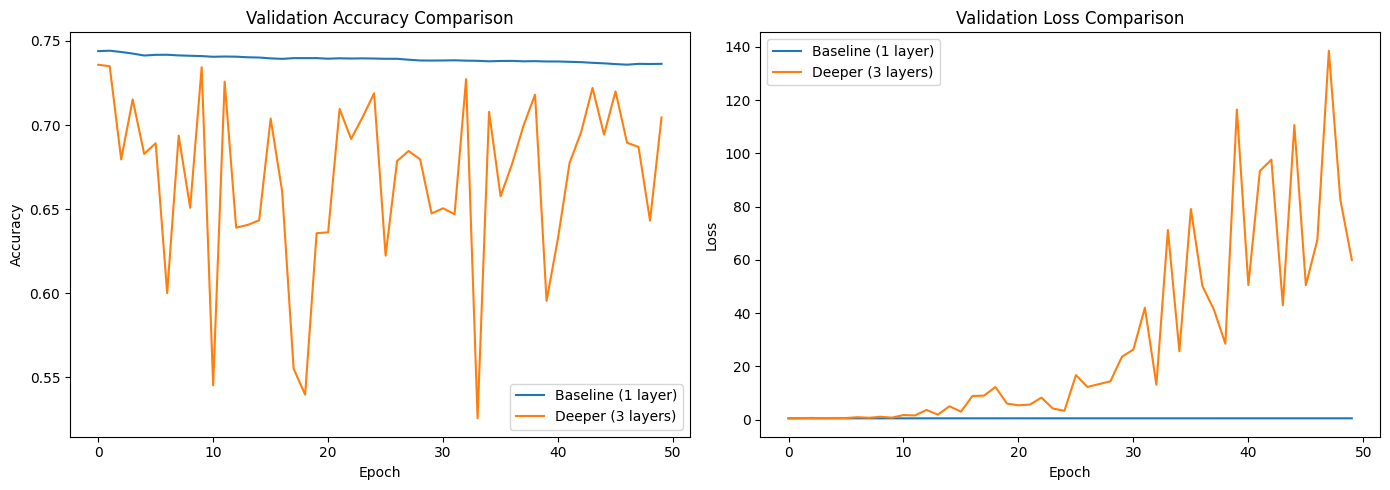

In [95]:
# Plot the comparison
plot_comparison(history_baseline, history_deeper)

### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** Did the deeper model perform better than the baseline? By how much?

**Question 2:** Looking at the training curves, did the deeper model overfit more than the baseline?

**Question 3:** Does adding more layers always make a model better? Why or why not?

**Answer 1:** The deeper model did perform better at least until the 19th epoch, but trailed off after that.

**Answer 2:** It looks like the deeper model appears to overfit because the accuracy drops off.

**Answer 3:** It does not always make the model better. It looks like more layers can cause overfitting.

---

## Part 7: Regularization with Dropout (10 pts)

**The Problem:** Deeper networks are more powerful, but they're also more prone to **overfitting** - memorizing the training data instead of learning general patterns.

**Dropout** is a regularization technique that randomly "turns off" a percentage of neurons during each training step. Think of it like a team where everyone needs to know the plays, not just the star player. If the star is randomly benched during practice, the whole team becomes stronger because everyone has to contribute.

### Task 7a: Build a Regularized Neural Network

Architecture:
- Dense(64, relu) -> Dropout(rate)
- Dense(32, relu) -> Dropout(rate)
- Dense(16, relu) -> Dropout(rate)
- Dense(1, sigmoid)

In [24]:
def build_regularized_nn(input_dim, dropout_rate=0.3):
    """
    Build a neural network with Dropout regularization.

    Architecture:
    - Dense(64, relu) -> Dropout(dropout_rate)
    - Dense(32, relu) -> Dropout(dropout_rate)
    - Dense(16, relu) -> Dropout(dropout_rate)
    - Dense(1, sigmoid)

    Compile with: optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']

    Args:
        input_dim (int): Number of input features
        dropout_rate (float): Fraction of neurons to drop (default 0.3)

    Returns:
        tf.keras.Model: Compiled Keras model
    """
    # Your code here

    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dropout(dropout_rate),
        Dense(16, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=['accuracy']
    )

    return model

### Task 7b: Compare Dropout Rates

Train two versions of the regularized model with different dropout rates:
- **Light dropout:** 0.2 (20% of neurons turned off)
- **Heavy dropout:** 0.5 (50% of neurons turned off)

This will help you see how dropout rate affects the balance between underfitting and overfitting.

In [25]:
# Train with light dropout (0.2)
reg_model_light = build_regularized_nn(n_features, dropout_rate=0.2)
history_light = train_model(reg_model_light, X_train_scaled, y_train, X_test_scaled, y_test)

# Train with heavy dropout (0.5)
reg_model_heavy = build_regularized_nn(n_features, dropout_rate=0.5)
history_heavy = train_model(reg_model_heavy, X_train_scaled, y_train, X_test_scaled, y_test)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.7086 - loss: 0.5935 - val_accuracy: 0.7434 - val_loss: 0.5335
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7335 - loss: 0.5501 - val_accuracy: 0.7410 - val_loss: 0.5361
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7358 - loss: 0.5448 - val_accuracy: 0.7408 - val_loss: 0.5364
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7360 - loss: 0.5443 - val_accuracy: 0.7398 - val_loss: 0.5379
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.7363 - loss: 0.5454 - val_accuracy: 0.7398 - val_loss: 0.5381
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.7350 - loss: 0.5474 - val_accuracy: 0.7382 - val_loss: 0.5380
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.7331 - loss: 0.5514 - val_accuracy: 0.7407 - val_loss: 0.5364
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.7319 -

### Task 7c: Visualize Dropout Comparison

Create a function that overlays the validation loss curves for the deeper model (no dropout), light dropout, and heavy dropout.

In [ ]:
def plot_dropout_comparison(history_no_dropout, history_light, history_heavy):
    """
    Compare validation loss curves across different dropout rates.

    Overlays validation loss for:
    - No dropout (deeper model)
    - Light dropout (0.2)
    - Heavy dropout (0.5)

    Args:
        history_no_dropout: Training history from model without dropout
        history_light: Training history from model with light dropout
        history_heavy: Training history from model with heavy dropout
    """
    plt.figure(figsize=(10, 6))
    plt.plot(history_no_dropout.history['val_loss'], label='No Dropout')
    plt.plot(history_light.history['val_loss'], label='Dropout 0.2')
    plt.plot(history_heavy.history['val_loss'], label='Dropout 0.5')
    plt.title('Validation Loss: Dropout Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Use whichever dropout model you prefer for the remaining parts
# (we'll use light dropout for verification)
reg_model = reg_model_light

# Check dropout layers exist
dropout_layers = [l for l in reg_model.layers if isinstance(l, tf.keras.layers.Dropout)]
assert len(dropout_layers) >= 2, "Model should contain Dropout layers"

# Evaluate
reg_metrics = evaluate_nn(reg_model, X_test_scaled, y_test)

print("[PASS] Part 7 Tests Passed!")
print(f"\n=== REGULARIZED NEURAL NETWORK RESULTS ===")
print(f"Light Dropout (0.2) Accuracy: {evaluate_nn(reg_model_light, X_test_scaled, y_test)['accuracy']:.4f}")
print(f"Heavy Dropout (0.5) Accuracy: {evaluate_nn(reg_model_heavy, X_test_scaled, y_test)['accuracy']:.4f}")
print(f"\nUsing for comparison - Accuracy: {reg_metrics['accuracy']:.4f}, F1: {reg_metrics['f1']:.4f}")

In [ ]:
# Plot the dropout comparison
plot_dropout_comparison(history_deeper, history_light, history_heavy)

### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** How did dropout change the gap between training and validation accuracy?

**Question 2:** Which dropout rate (0.2 or 0.5) worked better for this dataset? Why do you think that is?

**Question 3:** Explain in your own words why randomly turning off neurons during training helps the model generalize better.

**Answer 1:** The dropouts improves the accuracy and reduced the loss of the model. 

**Answer 2:** The 0.2 dropout rate had a smaller loss than the 0.5 dropout. This is probably because the model needs more neurons that have been trained for a smaller loss. 

**Answer 3:** The dropout can improve the loss by eliminating some of the overfitting that can occur in neural networks.

---

## Part 8: Early Stopping & Callbacks (5 pts)

**The Problem:** How do we know when to stop training? If we train for too few epochs, the model underfits. Too many, and it overfits. **Early stopping** solves this by monitoring validation loss and stopping when it stops improving.

Think of it like studying for an exam: at some point, more studying doesn't help and you start confusing yourself. Early stopping is like knowing when to put the textbook down.

### Task: Create a Training Function with Early Stopping

In [ ]:
def train_with_early_stopping(model, X_train, y_train, X_val, y_val, patience=5):
    """
    Train a model with early stopping callback.

    Uses EarlyStopping to monitor val_loss and stop when it stops improving.
    restore_best_weights=True ensures we keep the best version of the model.

    Args:
        model: Compiled Keras model
        X_train: Training features
        y_train: Training labels
        X_val: Validation features
        y_val: Validation labels
        patience (int): Epochs to wait before stopping (default 5)

    Returns:
        History: Keras training history object
    """
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        X_train, y_train,
        epochs=200,          # Set high - early stopping will handle it
        batch_size=64,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=1
    )
    return history

In [ ]:
# Build a fresh regularized model (use whichever dropout rate you preferred)
# and train it with early stopping

# YOUR CODE: Rebuild the regularized model with your preferred dropout rate
# es_model = build_regularized_nn(n_features, dropout_rate=___)

# YOUR CODE: Train with early stopping
# history_es = train_with_early_stopping(es_model, X_train_scaled, y_train, X_test_scaled, y_test)

In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Check that early stopping worked
actual_epochs = len(history_es.history['loss'])
print(f"Training stopped after {actual_epochs} epochs (max was 200)")
assert actual_epochs < 200, "Early stopping should have kicked in before 200 epochs"

# Evaluate
es_metrics = evaluate_nn(es_model, X_test_scaled, y_test)

print(f"\n[PASS] Part 8 Tests Passed!")
print(f"\n=== EARLY STOPPING RESULTS ===")
print(f"Accuracy: {es_metrics['accuracy']:.4f}")
print(f"F1 Score: {es_metrics['f1']:.4f}")

In [ ]:
# Plot the training curves for the early stopping model
plot_training_curves(history_es)

### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** How many epochs did training run before early stopping kicked in?

**Question 2:** Why is setting `epochs=200` with early stopping better than trying to guess the right number of epochs (like `epochs=50`)?

**Question 3:** What does the `patience` parameter control? What would happen if you set patience=1 vs patience=20?

*(Double-click here to write your answers)*

**Answer 1:**

**Answer 2:**

**Answer 3:**

---

## Part 9: Hyperparameter Tuning (10 pts)

> **Target: Your best tuned model must achieve > 73% accuracy on the test set.**

**The Problem:** So far, we've been guessing at the network architecture. Now let's systematically try different configurations to find the best one.

**Key Hyperparameters to Tune:**
- **Hidden layer sizes:** How many neurons in each layer?
- **Number of layers:** How deep should the network be?
- **Dropout rate:** How much regularization?
- **Learning rate:** How big are the weight updates?
- **Batch size:** How many samples per weight update?

### Task 9a: Build a Flexible Neural Network

Create a function that can build any architecture based on the hyperparameters you pass in.

In [ ]:
def build_custom_nn(input_dim, hidden_layers, dropout_rate=0.3, learning_rate=0.001):
    """
    Build a custom neural network with flexible architecture.

    Args:
        input_dim (int): Number of input features
        hidden_layers (list): List of neuron counts per layer, e.g. [128, 64, 32]
        dropout_rate (float): Dropout rate after each hidden layer (default 0.3)
        learning_rate (float): Learning rate for Adam optimizer (default 0.001)

    Returns:
        tf.keras.Model: Compiled Keras model
    """
    # Your code here
    # Hint: Loop through hidden_layers, adding Dense + Dropout for each
    # Use tf.keras.optimizers.Adam(learning_rate=learning_rate) for custom LR
    # Don't forget the output layer: Dense(1, activation='sigmoid')

    pass

### Task 9b: Run Experiments

Try at least **4 different configurations**. Use the template below to track your experiments.

In [ ]:
# Track your experiments here
configs = [
    {'name': 'Config 1', 'layers': [64, 32], 'dropout': 0.3, 'lr': 0.001, 'batch': 64},
    {'name': 'Config 2', 'layers': [128, 64, 32], 'dropout': 0.3, 'lr': 0.001, 'batch': 64},
    {'name': 'Config 3', 'layers': [128, 64, 32], 'dropout': 0.5, 'lr': 0.001, 'batch': 128},
    {'name': 'Config 4', 'layers': [64, 32, 16], 'dropout': 0.2, 'lr': 0.01, 'batch': 64},
    # Add more configurations!
]

results = []
for config in configs:
    print(f"\nTraining {config['name']}...")
    model = build_custom_nn(n_features, config['layers'], config['dropout'], config['lr'])
    history = train_with_early_stopping(model, X_train_scaled, y_train, X_test_scaled, y_test)
    metrics = evaluate_nn(model, X_test_scaled, y_test)
    actual_epochs = len(history.history['loss'])
    results.append({
        'Config': config['name'],
        'Layers': str(config['layers']),
        'Dropout': config['dropout'],
        'LR': config['lr'],
        'Batch': config['batch'],
        'Accuracy': metrics['accuracy'],
        'F1': metrics['f1'],
        'Epochs': actual_epochs
    })
    print(f"{config['name']}: Acc={metrics['accuracy']:.4f}, F1={metrics['f1']:.4f}, Epochs={actual_epochs}")

results_df = pd.DataFrame(results)
print("\n=== HYPERPARAMETER TUNING RESULTS ===")
print(results_df.to_string(index=False))

### Task 9c: Retrain the Best Model

Based on your experiments, select the best configuration and retrain it.

In [ ]:
# Retrain the best model based on your experiments
# UPDATE the hyperparameters below to match your best configuration!

best_model = build_custom_nn(
    n_features,
    hidden_layers=[128, 64, 32],  # UPDATE THIS with your best layers
    dropout_rate=0.3,              # UPDATE THIS with your best dropout
    learning_rate=0.001            # UPDATE THIS with your best LR
)

history_best = train_with_early_stopping(best_model, X_train_scaled, y_train, X_test_scaled, y_test)

In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Verify tuning
assert len(results) >= 4, f"Must try at least 4 configurations, tried {len(results)}"

# Evaluate best model
best_metrics = evaluate_nn(best_model, X_test_scaled, y_test)
assert best_metrics['accuracy'] > 0.73, f"Best model accuracy {best_metrics['accuracy']:.4f} seems too low"

print("[PASS] Part 9 Tests Passed!")
print(f"\n=== BEST TUNED MODEL RESULTS ===")
print(f"Accuracy:  {best_metrics['accuracy']:.4f}")
print(f"Precision: {best_metrics['precision']:.4f}")
print(f"Recall:    {best_metrics['recall']:.4f}")
print(f"F1 Score:  {best_metrics['f1']:.4f}")

### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** Which hyperparameters had the biggest impact on model performance?

**Question 2:** Were there any surprising results from your experiments?

**Question 3:** How does your best neural network compare to your best Unit 3 model (Random Forest or Gradient Boosting)? Is deep learning always better for tabular data?

*(Double-click here to write your answers)*

**Answer 1:**

**Answer 2:**

**Answer 3:**

---

## Part 10: Fashion-MNIST -- Image Exploration & Preprocessing (5 pts)

**New Mission:** ShopSmart is launching a **fashion e-commerce platform** and needs an automated system for classifying product images into categories. You'll build a Convolutional Neural Network (CNN) to handle this.

We'll use the **Fashion-MNIST dataset**, a collection of 70,000 grayscale images (28x28 pixels) of 10 fashion categories. This is a standard benchmark dataset built right into Keras.

### Load the Fashion-MNIST Dataset

In [ ]:
# Load Fashion-MNIST dataset
from tensorflow.keras.datasets import fashion_mnist
(X_train_img, y_train_img), (X_test_img, y_test_img) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training set: {X_train_img.shape}")
print(f"Test set: {X_test_img.shape}")
print(f"Pixel value range: {X_train_img.min()} to {X_train_img.max()}")
print(f"Data type: {X_train_img.dtype}")

### Explore the Data

Let's visualize some sample images to understand what we're working with.

In [ ]:
# Visualize one sample image from each class (2x5 grid)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    # Find the first image of each class
    idx = np.where(y_train_img == i)[0][0]
    ax.imshow(X_train_img[idx], cmap='gray')
    ax.set_title(class_names[i], fontsize=11)
    ax.axis('off')
plt.suptitle('Fashion-MNIST: One Sample Per Class', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Show raw pixel values for one image
print(f"Image shape: {X_train_img[0].shape}")
print(f"\nRaw pixel values (first 10x10 corner):")
print(X_train_img[0][:10, :10])

In [ ]:
# Plot class distribution
plt.figure(figsize=(10, 5))
unique, counts = np.unique(y_train_img, return_counts=True)
plt.bar([class_names[i] for i in unique], counts, color='steelblue')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Fashion-MNIST Class Distribution (Training Set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Task: Preprocess Images for CNN

Neural networks work best with normalized inputs. We need to:
1. **Normalize pixel values** from 0-255 to 0.0-1.0
2. **Reshape** to add a channel dimension (CNNs expect a channel dimension for the color channels)

In [ ]:
def preprocess_images(X_train, X_test):
    """
    Preprocess image data for CNN training.

    Steps:
    1. Normalize: divide by 255.0 to scale pixels to [0, 1]
    2. Reshape: add channel dimension - from (N, 28, 28) to (N, 28, 28, 1)

    Args:
        X_train: Training images, shape (60000, 28, 28)
        X_test: Test images, shape (10000, 28, 28)

    Returns:
        tuple: (X_train_processed, X_test_processed)
    """
    # Your code here
    # Hint for reshape: X_train.reshape(-1, 28, 28, 1) or X_train[..., np.newaxis]

    pass

In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Preprocess images
X_train_processed, X_test_processed = preprocess_images(X_train_img, X_test_img)

# Basic Verification
assert X_train_processed.shape == (60000, 28, 28, 1), f"Expected (60000, 28, 28, 1), got {X_train_processed.shape}"
assert X_test_processed.shape == (10000, 28, 28, 1), f"Expected (10000, 28, 28, 1), got {X_test_processed.shape}"
assert X_train_processed.max() <= 1.0, "Pixel values should be normalized to [0, 1]"
assert X_train_processed.min() >= 0.0, "Pixel values should be normalized to [0, 1]"

print("[PASS] Part 10 Tests Passed!")
print(f"\nTraining images: {X_train_processed.shape}")
print(f"Test images: {X_test_processed.shape}")
print(f"Pixel range: [{X_train_processed.min():.1f}, {X_train_processed.max():.1f}]")

### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** Why do we normalize pixel values from 0-255 to 0.0-1.0?

**Question 2:** What does the extra dimension in (28, 28, 1) represent? What would it be for a color image?

**Question 3:** Looking at the sample images, which fashion categories do you think will be hardest to tell apart? Why?

*(Double-click here to write your answers)*

**Answer 1:**

**Answer 2:**

**Answer 3:**

---

## Part 11: Build & Train a CNN (10 pts)

> **Target: Your CNN must achieve > 87% accuracy on the Fashion-MNIST test set.**

**The Big Idea:** Dense layers look at all features at once. **Convolutional layers** look at small patches of the image, learning local patterns like edges, textures, and shapes. This makes them much better at understanding images.

Think of it this way: when you look at a shirt, you don't analyze every pixel individually. You recognize patterns - a collar, sleeves, buttons. CNNs work the same way, scanning the image in small patches to build up an understanding of the whole.

### Key CNN Concepts:
- **Conv2D:** Slides a small filter (3x3) across the image, detecting patterns
- **MaxPooling2D:** Shrinks the image by keeping the strongest signals (reduces computation)
- **Flatten:** Converts 2D feature maps to a 1D vector for the Dense layers
- **softmax:** Outputs probabilities for each of the 10 classes (they sum to 1.0)

### Task: Build a CNN

Architecture:
- Conv2D(32, 3x3, relu) -> MaxPooling2D(2x2)
- Conv2D(64, 3x3, relu) -> MaxPooling2D(2x2)
- Flatten -> Dense(64, relu) -> Dropout(0.5) -> Dense(10, softmax)

In [ ]:
def build_cnn():
    """
    Build a Convolutional Neural Network for Fashion-MNIST classification.

    Architecture:
    - Conv2D(32, (3,3), relu, input_shape=(28, 28, 1))
    - MaxPooling2D((2,2))
    - Conv2D(64, (3,3), relu)
    - MaxPooling2D((2,2))
    - Flatten()
    - Dense(64, relu)
    - Dropout(0.5)
    - Dense(10, softmax)

    Compile with:
    - optimizer='adam'
    - loss='sparse_categorical_crossentropy'
    - metrics=['accuracy']

    Returns:
        tf.keras.Model: Compiled CNN model
    """
    model = Sequential([
        # YOUR CODE
    ])

    model.compile(
        # YOUR CODE
    )

    return model

In [ ]:
# Build and display the CNN architecture
cnn_model = build_cnn()
cnn_model.summary()

In [ ]:
# Train the CNN
history_cnn = cnn_model.fit(
    X_train_processed, y_train_img,
    epochs=10,
    batch_size=128,
    validation_data=(X_test_processed, y_test_img),
    verbose=1
)

In [ ]:
# Plot CNN training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_cnn.history['loss'], label='Training Loss')
ax1.plot(history_cnn.history['val_loss'], label='Validation Loss')
ax1.set_title('CNN Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history_cnn.history['accuracy'], label='Training Accuracy')
ax2.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('CNN Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Visualize CNN predictions on test images
y_pred_cnn = cnn_model.predict(X_test_processed)
y_pred_classes = np.argmax(y_pred_cnn, axis=1)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test_img[i], cmap='gray')
    predicted = class_names[y_pred_classes[i]]
    actual = class_names[y_test_img[i]]
    color = 'green' if y_pred_classes[i] == y_test_img[i] else 'red'
    ax.set_title(f"Pred: {predicted}\nActual: {actual}", color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('CNN Predictions on Fashion-MNIST', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Evaluate CNN
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_processed, y_test_img, verbose=0)

assert cnn_accuracy > 0.87, f"CNN accuracy {cnn_accuracy:.4f} should be >87%"

print("[PASS] Part 11 Tests Passed!")
print(f"\n=== CNN RESULTS ===")
print(f"Test Loss:     {cnn_loss:.4f}")
print(f"Test Accuracy: {cnn_accuracy:.4f}")

### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** How does CNN accuracy on images compare to your neural network accuracy on tabular (customer) data? Why might there be a difference?

**Question 2:** Why do we use softmax with 10 outputs for Fashion-MNIST instead of sigmoid with 1 output like we did for churn?

**Question 3:** Looking at the prediction visualization, do you see any patterns in which items the CNN gets wrong? Which categories are most often confused?

**Question 4:** How is a Conv2D layer different from a Dense layer? Why is Conv2D better for images?

*(Double-click here to write your answers)*

**Answer 1:**

**Answer 2:**

**Answer 3:**

**Answer 4:**

---

## Part 12: Model Comparison & Business Recommendations (10 pts)

**The Problem:** You've now built models across both Unit 3 and Unit 4. ShopSmart needs a clear recommendation: which model should they deploy for churn prediction, and is the CNN ready for their fashion platform?

### Task 12a: Create a Cross-Unit Model Comparison Table

Fill in your Unit 3 results alongside your Unit 4 results.

In [ ]:
# Create a comparison DataFrame with models from BOTH units
comparison_data = {
    'Model': [
        'Unit 3: Logistic Regression',
        'Unit 3: Best Ensemble',
        'Unit 4: Baseline NN (1 layer)',
        'Unit 4: Deeper NN (3 layers)',
        'Unit 4: Regularized NN (dropout)',
        'Unit 4: Best Tuned NN'
    ],
    'Type': [
        'Traditional ML', 'Traditional ML',
        'Deep Learning', 'Deep Learning', 'Deep Learning', 'Deep Learning'
    ],
    'Accuracy': [
        # YOUR UNIT 3 RESULTS HERE
        0.0,  # Replace with your Unit 3 logistic regression accuracy
        0.0,  # Replace with your Unit 3 best model accuracy
        baseline_metrics['accuracy'],
        deeper_metrics['accuracy'],
        reg_metrics['accuracy'],
        best_metrics['accuracy']
    ],
    'F1': [
        # YOUR UNIT 3 RESULTS HERE
        0.0,  # Replace with your Unit 3 logistic regression F1
        0.0,  # Replace with your Unit 3 best model F1
        baseline_metrics['f1'],
        deeper_metrics['f1'],
        reg_metrics['f1'],
        best_metrics['f1']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("=== CROSS-UNIT MODEL COMPARISON ===")
print(comparison_df.to_string(index=False))

### Task 12b: Visualize the Comparison

In [ ]:
# Bar chart comparing all models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
colors = ['#2196F3' if t == 'Traditional ML' else '#FF9800' for t in comparison_df['Type']]
ax1.barh(comparison_df['Model'], comparison_df['Accuracy'], color=colors)
ax1.set_xlabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_xlim(0, 1)
for i, v in enumerate(comparison_df['Accuracy']):
    ax1.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

# F1 comparison
ax2.barh(comparison_df['Model'], comparison_df['F1'], color=colors)
ax2.set_xlabel('F1 Score')
ax2.set_title('Model F1 Score Comparison')
ax2.set_xlim(0, 1)
for i, v in enumerate(comparison_df['F1']):
    ax2.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Traditional ML'),
                   Patch(facecolor='#FF9800', label='Deep Learning')]
ax1.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

### Task 12c: CNN Results Summary

In [ ]:
# Per-class accuracy for CNN
from sklearn.metrics import classification_report

print("=== CNN PER-CLASS RESULTS ===")
print(classification_report(y_test_img, y_pred_classes, target_names=class_names))

In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

assert comparison_df.shape[0] >= 6, f"Comparison table should have at least 6 models, got {comparison_df.shape[0]}"
assert 'Accuracy' in comparison_df.columns, "Missing 'Accuracy' column"
assert 'F1' in comparison_df.columns, "Missing 'F1' column"

print("[PASS] Part 12 Tests Passed!")
print(f"\nCompared {comparison_df.shape[0]} models across Unit 3 and Unit 4")

### Business Recommendations

> **Please answer the questions below. They are a required part of the assignment!**

**Question 1 - Churn Prediction Deployment:** Which model would you recommend ShopSmart deploy for churn prediction -- a traditional ML model from Unit 3 or a neural network from Unit 4? Justify your answer with specific numbers.

**Question 2 - When to Use Deep Learning vs Traditional ML:** Based on your experience in this capstone, when should a company use deep learning and when should they stick with traditional ML? Consider: data type, training time, interpretability, and performance.

**Question 3 - Product Catalog Classifier:** Based on the CNN results, is the model ready for production use on ShopSmart's fashion e-commerce platform? What accuracy would you consider acceptable? What improvements would you suggest?

**Question 4 - Top 3 Actionable Recommendations:** Give ShopSmart your top 3 data-driven recommendations based on everything you've learned in Units 3 and 4.

*(Double-click here to write your answers)*

**Answer 1 - Churn Prediction Deployment:**

**Answer 2 - Deep Learning vs Traditional ML:**

**Answer 3 - Product Catalog Classifier:**

**Answer 4 - Top 3 Recommendations:**
1.
2.
3.

---

## Final Summary

Run this cell to see a summary of everything you built!

In [ ]:
print("=" * 60)
print("UNIT 4 CAPSTONE SUMMARY")
print("=" * 60)

print(f"\nCHURN PREDICTION DATASET")
print(f"   Customers: 100,000")
print(f"   Features: {n_features}")
print(f"   Churn Rate: {y_train.mean():.1%}")

print(f"\nNEURAL NETWORK RESULTS (Churn Prediction)")
print(f"   Baseline NN Accuracy:     {baseline_metrics['accuracy']:.4f}")
print(f"   Deeper NN Accuracy:       {deeper_metrics['accuracy']:.4f}")
print(f"   Regularized NN Accuracy:  {reg_metrics['accuracy']:.4f}")
print(f"   Best Tuned NN Accuracy:   {best_metrics['accuracy']:.4f}")
print(f"   Best Tuned NN F1 Score:   {best_metrics['f1']:.4f}")

print(f"\nCNN RESULTS (Fashion-MNIST)")
print(f"   Images: 60,000 train / 10,000 test")
print(f"   Classes: {len(class_names)}")
print(f"   CNN Test Accuracy: {cnn_accuracy:.4f}")

print(f"\nMODELS BUILT")
print(f"   1. Baseline Neural Network (1 hidden layer)")
print(f"   2. Deeper Neural Network (3 hidden layers)")
print(f"   3. Regularized Neural Network (dropout)")
print(f"   4. Early Stopping Neural Network")
print(f"   5. Tuned Neural Network (hyperparameter search)")
print(f"   6. Convolutional Neural Network (CNN)")

print("\n" + "=" * 60)
print("Great work completing Unit 4!")
print("=" * 60)

---

## Ready to Submit?

### Checklist:
- [ ] All **assert tests pass** (no errors when running the test cells)
- [ ] All **Written Reflections** are answered thoughtfully
- [ ] **Hyperparameter tuning** was performed with at least 4 configurations
- [ ] **Dropout comparison** with two different rates was completed
- [ ] **CNN** was built, trained, and evaluated
- [ ] **Model comparison table** includes models from both Unit 3 and Unit 4
- [ ] **Business recommendations** are specific and actionable
- [ ] Code has **comments** explaining your logic

### Submission:
Turn in your completed notebook on Canvas by the due date.

Remember: You can resubmit after receiving feedback!

---

*Congratulations on completing the Deep Learning capstone! You've gone from building your first neuron to training a CNN that classifies images -- that's a huge accomplishment.*